To analytically define the ratio X between the area of a circle and the area of a square with length 1 = diameter of circle:

Area of square = 1^2 = 1
radius of circle = diameter / 2 = length of square / 2 = 1 / 2
Area of circle = π * (radius)^2 = π * (1/2)^2 = π / 4

Therefore the ratio X is given by: 
X = Area of circle / Area of square = (π / 4) / 1 = π / 4.

$\hat{X}$ = $\frac{\pi}{4}$ = X

$\hat{X}$ * 4 = π

In [1]:
import numpy as np

# Generate 10,000 random (x, y) pairs uniformly in [0, 1] x [0, 1]
pairs = np.random.uniform(0, 1, size=(10000, 2))
circle_count = 0
for i in range(len(pairs)):
    if (pairs[i][0] - 0.5)**2 + (pairs[i][1] - 0.5)**2 <= (0.5)**2:
        circle_count += 1
X_hat = circle_count / len(pairs)
print(X_hat)

0.7955


In [2]:
pi_hat = X_hat * 4
print(pi_hat)

3.182


In [3]:
x_1 = np.random.uniform(0, 1, size=(10000))
x_2 = x_1 + np.random.uniform(-0.1, 0.1, size=(10000))
pairs2 = np.column_stack((x_1, x_2))
circle_count2 = 0
for i in range(len(pairs2)):
    if (pairs2[i][0] - 0.5)**2 + (pairs2[i][1] - 0.5)**2 <= (0.5)**2:
        circle_count2 += 1
X_hat2 = circle_count2 / len(pairs2)
print(X_hat2)
pi_hat2 = X_hat2 * 4
print(pi_hat2)

0.7012
2.8048


The estimates when we include random noise are lower than the estimates without noise. This is due to some points now falling outside the square due to the added noise, which reduces the number of points that fall within the circle, thus lowering the estimate of π.

## Exercise 2

This is a control problem, because we want to find the optimal policy that maximizes the expected reward. The epsilon greedy algorithm for MABs specifically does this by balancing exploration and exploitation, allowing us to find the best action while still exploring other options to ensure we don't miss out on potentially better rewards.

The expected reward of pulling an arm corresponds to a action-value function, which estimates the expected reward of doing an action given a state.

# 2  
A trajectory for a MAB would correspond to the seqence of actions taken and rewards recieved over a full run of the algorithm.

# 3
A collection of trajectories would correspond to a collection of runs of the algorithm. E.g. multiple experiments.

# 4
All the MAB algorithms we discussed corresponds to MC control, as each trajectory is generated by an updating policy.

# 5
MC prediction would be equivalent to estimating the expected reward of pulling an arm by averaging the rewards received from pulling that arm over multiple trajectories. This would give us an estimate of the action-value function for that arm, which is what MC prediction aims to do.

# 6

epsilon is a hyperparameter that controls how often we select a random lever in the MAB, and equivalently how often we select a random action in the MC control problem.

# 7
You lose information about the states of the environment as the MAB problem is only a single state problem.







## Exercise 3

# 1
E[R] = 0 * 0.35 + 5 * 0.3 + 10 * 0.25 + 20 * 0.1 = 4.25

E[S] = 0 * 0.3 + 5 * 0.35 + 10 * 0.3 + 20 * 0.05 = 4.25



In [4]:
# 3.2

def slot_machine_R():
    return np.random.choice([0, 5, 10, 20], p=[0.35, 0.3, 0.25, 0.1])

def slot_machine_S():
    return np.random.choice([0, 5, 10, 20], p=[0.3, 0.35, 0.3, 0.05])

# 3.3
rewards_S = []
for i in range(10000):
    rewards_S.append(slot_machine_S())
print("Expected reward for slot machine S:", np.mean(rewards_S))


Expected reward for slot machine S: 5.798


In [5]:
rho = {0: 0.35 / 0.3, 5: 0.3 / 0.35, 10: 0.25 / 0.3, 20: 0.1 / 0.05}  # rho[x] = P_R(x) / P_S(x)
rewards_R = []
for reward in rewards_S:
    rewards_R.append(reward * rho[reward])

print("Expected reward for slot machine R:", np.mean(rewards_R))

Expected reward for slot machine R: 6.042928571428573


In [6]:
# 3.4 - S' with uniform distribution
def slot_machine_S_prime():
    return np.random.choice([0, 5, 10, 20], p=[0.25, 0.25, 0.25, 0.25])

rewards_S_prime = [slot_machine_S_prime() for _ in range(10000)]
print("Estimated E[S']:", np.mean(rewards_S_prime))

rho_prime = {0: 0.35 / 0.25, 5: 0.3 / 0.25, 10: 0.25 / 0.25, 20: 0.1 / 0.25}
weighted_rewards_R_from_S_prime = [reward * rho_prime[reward] for reward in rewards_S_prime]

print("Estimated E[R] via importance sampling from S':", np.mean(weighted_rewards_R_from_S_prime))

Estimated E[S']: 8.764
Estimated E[R] via importance sampling from S': 6.045


In [7]:
# 3.5 - S'' with highly skewed middle outcomes
def slot_machine_S_double_prime():
    return np.random.choice([0, 5, 10, 20], p=[0.001, 0.499, 0.499, 0.001])

rewards_S_double_prime = [slot_machine_S_double_prime() for _ in range(10000)]
print("Estimated E[S'']:", np.mean(rewards_S_double_prime))

rho_double_prime = {0: 0.35 / 0.001, 5: 0.3 / 0.499, 10: 0.25 / 0.499, 20: 0.1 / 0.001}
weighted_rewards_R_from_S_double_prime = [reward * rho_double_prime[reward] for reward in rewards_S_double_prime]

print("Estimated E[R] via importance sampling from S'':", np.mean(weighted_rewards_R_from_S_double_prime))

# Optional diagnostics for comparison
print("Var of weighted rewards (S):", np.var(rewards_R))
print("Var of weighted rewards (S'):", np.var(weighted_rewards_R_from_S_prime))
print("Var of weighted rewards (S''):", np.var(weighted_rewards_R_from_S_double_prime))

Estimated E[S'']: 7.4585
Estimated E[R] via importance sampling from S'': 4.587675350701403
Var of weighted rewards (S): 71.14258911054421
Var of weighted rewards (S'): 13.741575
Var of weighted rewards (S''): 1195.877966102545


### 3.6 - Why the results differ
All three importance-sampling estimates target the same quantity $E[R]$, so with many samples they should be close to the true value.

The main difference is **variance**, caused by how different the behavior distribution is from $R$ (the size/spread of $\rho=\frac{P_R}{P_{behavior}}$):
- For $S$ and especially $S'$, probabilities overlap reasonably well with $R$, so weights are moderate and estimates are stable.
- For $S''$, rare events under $S''$ (0 and 20) get very large weights ($\rho(0)=350$, $\rho(20)=100$), which can create large fluctuations when those outcomes appear.

So the estimates can differ in finite samples because importance sampling is unbiased in expectation but can have very high variance when behavior and target policies/distributions are very different.

## Exercise 5



In [8]:
from pathlib import Path
import pickle

pickle_path = Path("trajectories.pickle")

with pickle_path.open("rb") as f:
    trajectories = pickle.load(f)

print(f"Loaded {len(trajectories)} trajectories from {pickle_path}")

Loaded 1000 trajectories from trajectories.pickle


Estimated values for 2924 states


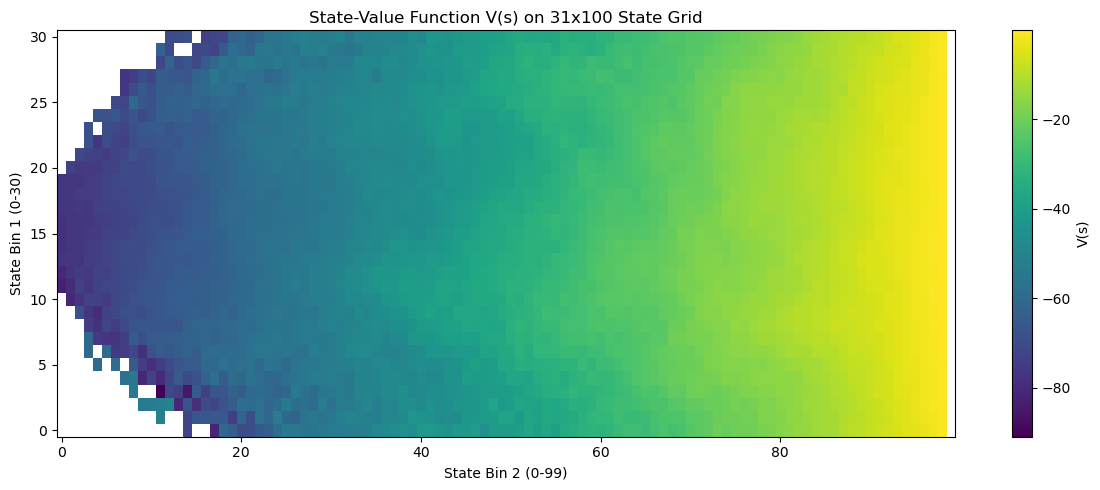

In [13]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

def _extract_state_reward(step):
    # Supports common step formats: (state, reward), (state, action, reward), dict
    if isinstance(step, dict):
        if "state" in step and "reward" in step:
            return step["state"], step["reward"]
        raise ValueError("Dict step must contain 'state' and 'reward' keys")

    if isinstance(step, (list, tuple)):
        if len(step) == 2:
            state, reward = step
            return state, reward
        if len(step) >= 3:
            state = step[0]
            reward = step[2]
            return state, reward

    raise ValueError(f"Unsupported trajectory step format: {type(step)}")

def mc_state_value(trajectories, gamma=1.0):
    state_returns = defaultdict(list)

    for trajectory in trajectories:
        G = 0.0
        for t in reversed(range(len(trajectory))):
            state, reward = _extract_state_reward(trajectory[t])
            G = reward + gamma * G
            state_returns[state].append(G)

    state_values = {
        state: sum(returns) / len(returns)
        for state, returns in state_returns.items()
    }
    return state_values

state_values = mc_state_value(trajectories, gamma=1.0)
print(f"Estimated values for {len(state_values)} states")


def mc_action_value(trajectories, gamma=1.0):
    state_action_returns = defaultdict(list)

    for trajectory in trajectories:
        G = 0.0
        for t in reversed(range(len(trajectory))):
            step = trajectory[t]
            if isinstance(step, dict) and "state" in step and "action" in step and "reward" in step:
                state = step["state"]
                action = step["action"]
                reward = step["reward"]
            elif isinstance(step, (list, tuple)):
                if len(step) >= 3:
                    state = step[0]
                    action = step[1]
                    reward = step[2]
                else:
                    continue  # Skip steps that don't have enough elements
            else:
                continue  # Skip unsupported formats

            G = reward + gamma * G
            state_action_returns[(state, action)].append(G)

    state_action_values = {
        (state, action): sum(returns) / len(returns)
        for (state, action), returns in state_action_returns.items()
    }
    return state_action_values


# 31x100 heatmap grid for V(s): rows = state-bin-1 [0..30], cols = state-bin-2 [0..99]
value_grid = np.full((31, 100), np.nan, dtype=float)

for state, value in state_values.items():
    state_arr = np.asarray(state).ravel()
    if state_arr.size < 2:
        continue

    s1_idx = int(np.rint(state_arr[0]))
    s2_idx = int(np.rint(state_arr[1]))

    if 0 <= s1_idx < 31 and 0 <= s2_idx < 100:
        value_grid[s1_idx, s2_idx] = value

plt.figure(figsize=(12, 5))
im = plt.imshow(
    value_grid,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="nearest"
)
plt.colorbar(im, label="V(s)")
plt.title("State-Value Function V(s) on 31x100 State Grid")
plt.xlabel("State Bin 2 (0-99)")
plt.ylabel("State Bin 1 (0-30)")
plt.tight_layout()
plt.show()

# .4

Yes, you can perform MC improvement 

Estimated Q(s,a) for 14138 state-action pairs
Actions seen: [0, 1, 2, 3, 4]


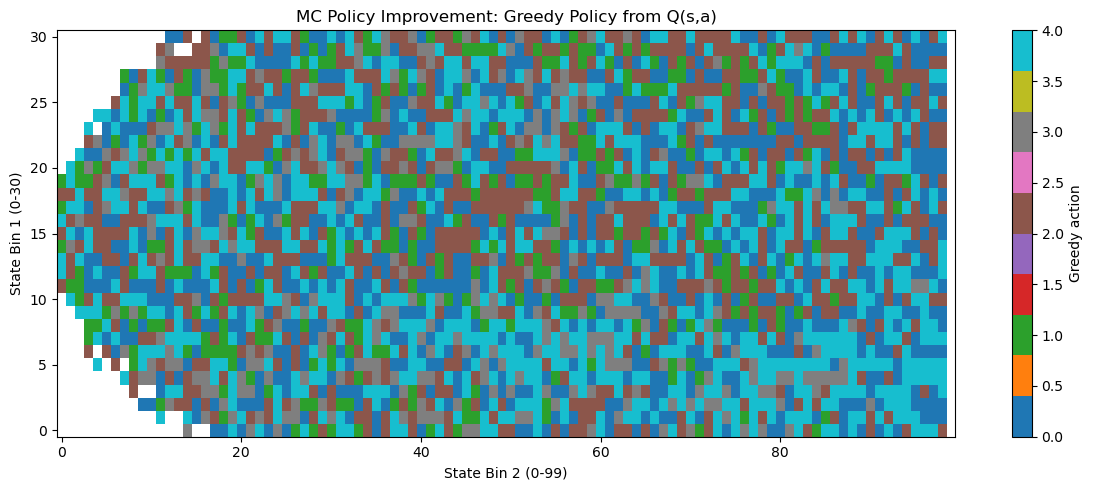

In [14]:
# MC policy improvement: estimate Q(s,a) and derive greedy policy pi(s)=argmax_a Q(s,a)
q_values = mc_action_value(trajectories, gamma=1.0)
print(f"Estimated Q(s,a) for {len(q_values)} state-action pairs")

# Collect all actions seen in data (for reference)
actions_seen = sorted({int(a) for (_, a) in q_values.keys()})
print(f"Actions seen: {actions_seen}")

# Build greedy policy from Q(s,a)
policy = {}
for (state, action), q in q_values.items():
    if state not in policy or q > policy[state][1]:
        policy[state] = (int(action), q)

# 31x100 policy grid (action index per state)
policy_grid = np.full((31, 100), np.nan, dtype=float)
for state, (best_action, _) in policy.items():
    state_arr = np.asarray(state).ravel()
    if state_arr.size < 2:
        continue

    s1_idx = int(np.rint(state_arr[0]))
    s2_idx = int(np.rint(state_arr[1]))

    if 0 <= s1_idx < 31 and 0 <= s2_idx < 100:
        policy_grid[s1_idx, s2_idx] = best_action

# Plot improved (greedy) policy
plt.figure(figsize=(12, 5))
im = plt.imshow(
    policy_grid,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="tab10"
)
cbar = plt.colorbar(im)
cbar.set_label("Greedy action")
plt.title("MC Policy Improvement: Greedy Policy from Q(s,a)")
plt.xlabel("State Bin 2 (0-99)")
plt.ylabel("State Bin 1 (0-30)")
plt.tight_layout()
plt.show()